In [1]:
import numpy as np
import pandas as pd

In [41]:
#random seed
np.random.seed(42)

set1no = 100
set2no = 900

In [62]:
df1 = pd.DataFrame({
        "feature_1": np.random.normal(loc=0,scale=1, size=set1no),
        "feature_2": np.random.normal(loc=0,scale=1, size=set1no),
        "target": [1]* set1no     
})

df2 = pd.DataFrame({
        "feature_1": np.random.normal(loc=0,scale=1, size=set2no),
        "feature_2": np.random.normal(loc=0,scale=1, size=set2no),
        "target": [0]* set2no   
})

In [63]:
df1.head()

,feature_1,feature_2,target
0,-0.675178,0.376410,1
1,-0.144519,-0.902052,1
2,-0.792420,-0.869663,1
3,-0.307962,1.125435,1
4,-1.893615,-1.189412,1


In [64]:
df2.head()

,feature_1,feature_2,target
0,1.804348,-0.706893,0
1,-0.190904,0.855556,0
2,0.719758,1.649481,0
3,-1.293273,1.070611,0
4,-0.956436,-0.729602,0


In [65]:
df = pd.concat([df1,df2]).reset_index(drop=True)

In [66]:
df

,feature_1,feature_2,target
0,-0.675178,0.376410,1
1,-0.144519,-0.902052,1
2,-0.792420,-0.869663,1
3,-0.307962,1.125435,1
4,-1.893615,-1.189412,1
...,...,...,...
995,1.279465,0.028458,0
996,1.041725,-2.077812,0
997,0.583544,-0.320298,0
998,-0.129517,1.643378,0


In [67]:
df["target"].unique()

array([1, 0])

In [68]:
df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [69]:
df_minority = df[df["target"] == 1]

In [70]:
df_minority

,feature_1,feature_2,target
0,-0.675178,0.376410,1
1,-0.144519,-0.902052,1
2,-0.792420,-0.869663,1
3,-0.307962,1.125435,1
4,-1.893615,-1.189412,1
...,...,...,...
95,-0.075764,-0.661982,1
96,0.670481,0.425887,1
97,-1.071857,0.019148,1
98,-1.553759,-0.641487,1


In [71]:
df_majority = df[df["target"] == 0]

In [72]:
df_majority

,feature_1,feature_2,target
100,1.804348,-0.706893,0
101,-0.190904,0.855556,0
102,0.719758,1.649481,0
103,-1.293273,1.070611,0
104,-0.956436,-0.729602,0
...,...,...,...
995,1.279465,0.028458,0
996,1.041725,-2.077812,0
997,0.583544,-0.320298,0
998,-0.129517,1.643378,0


## bu işlemler datayı çogaltma (kopyalayarak çogaltma gibi bir şey)

In [73]:
from sklearn.utils import resample

In [74]:
df_minority_upsample = resample(df_minority,replace=True,n_samples=len(df_majority),random_state=42)

In [75]:
df_minority_upsample.shape

(900, 3)

In [78]:
df_minority.shape

(100, 3)

In [79]:
df_minority_upsample["target"].value_counts() 

target
1    900
Name: count, dtype: int64

In [80]:
df_majority.shape

(900, 3)

In [81]:
df_minority_upsample.shape

(900, 3)

In [82]:
df_upsampled = pd.concat([df_majority,df_minority_upsample])

In [84]:
df_upsampled.tail()

,feature_1,feature_2,target
52,-0.658116,0.020886,1
65,-0.582759,-1.015094,1
76,0.615771,-1.607661,1
42,-0.524088,0.173342,1
74,-0.617652,-0.835143,1


In [87]:
df_upsampled.count()

feature_1    1800
feature_2    1800
target       1800
dtype: int64

In [90]:
df_upsampled["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [93]:
df_majority_downsampled = resample(df_majority,replace=True,n_samples=len(df_minority),random_state=42)

In [106]:
df_majority_downsampled[df_majority_downsampled["target"] == 0].count() 

feature_1    100
feature_2    100
target       100
dtype: int64

In [107]:
df_majority_downsampled.shape

(100, 3)

In [108]:
df_minority.shape

(100, 3)

In [109]:
df_downsampled = pd.concat([df_majority_downsampled,df_minority])

In [113]:
df_downsampled["target"].value_counts()

target
0    100
1    100
Name: count, dtype: int64

In [115]:
df

,feature_1,feature_2,target
0,-0.675178,0.376410,1
1,-0.144519,-0.902052,1
2,-0.792420,-0.869663,1
3,-0.307962,1.125435,1
4,-1.893615,-1.189412,1
...,...,...,...
995,1.279465,0.028458,0
996,1.041725,-2.077812,0
997,0.583544,-0.320298,0
998,-0.129517,1.643378,0


## SMOTE   (veri kopyalama algoritması var belli algoritmaya göre veriyi küçültür yada büyültür)

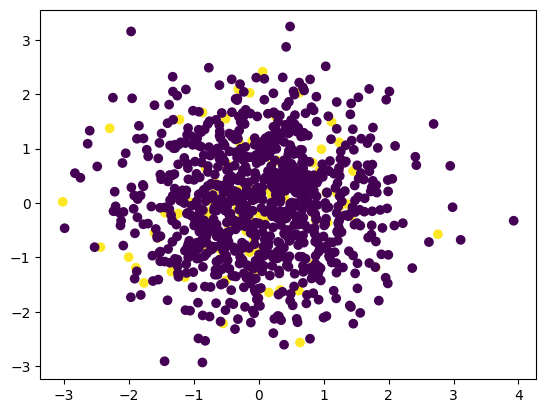

In [130]:
import matplotlib.pyplot as plt
plt.scatter(df['feature_1'],df['feature_2'],c=df["target"])

In [120]:
!pip install imblearn


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
from imblearn.over_sampling import SMOTE

In [122]:
oversample = SMOTE()

In [125]:
(X,y) = oversample.fit_resample(df[["feature_1","feature_2"]],df["target"])

In [126]:
X

,feature_1,feature_2
0,-0.675178,0.376410
1,-0.144519,-0.902052
2,-0.792420,-0.869663
3,-0.307962,1.125435
4,-1.893615,-1.189412
...,...,...
1795,0.566425,1.954940
1796,1.090691,1.391899
1797,-0.200667,-0.294802
1798,-0.307283,-0.476490


In [127]:
y

0       1
1       1
2       1
3       1
4       1
       ..
1795    1
1796    1
1797    1
1798    1
1799    1
Name: target, Length: 1800, dtype: int64

In [131]:
oversample_df = pd.concat([X,y],axis=1)

In [134]:
oversample_df["target"].value_counts()

target
1    900
0    900
Name: count, dtype: int64

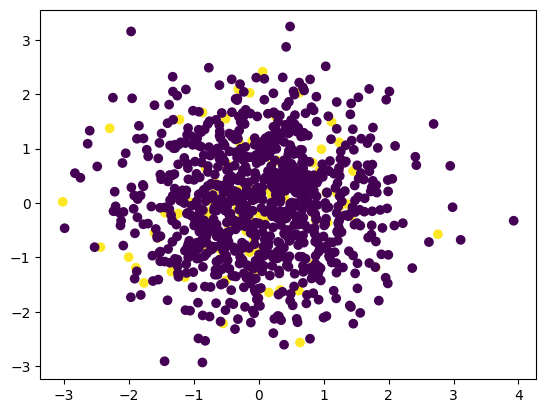

In [135]:
plt.scatter(df['feature_1'],df['feature_2'],c=df["target"]) #öncesi

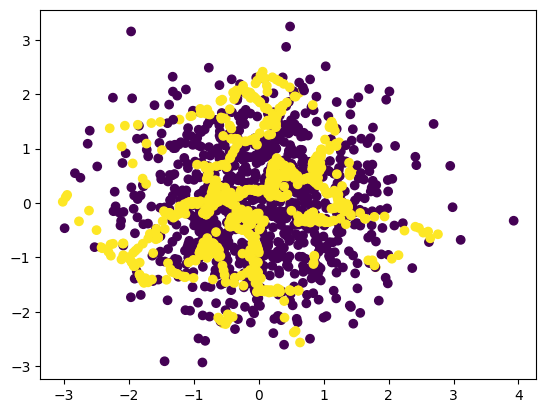

In [137]:
plt.scatter(oversample_df['feature_1'],oversample_df['feature_2'],c=oversample_df["target"]) #sonrası